# Chapter 62: The Kaggle Landscape, 2024 to 2026

**At what deadline does a stronger model stop being the better pipeline, and what does a retained feasible reference recover?**

The chapter's rule is to budget loading, preprocessing, inference and fallbacks together and to retain a feasible reference. A model with better completed-query accuracy cannot win if the queries it does not finish are scored as misses.

*Constructed data and counted work, not timed work. The deadlines are shares of one pipeline's cost; no claim is made about any actual Kaggle runtime limit or hardware, which are competition-specific and change.*

## The experiment

Five constructed binary tasks with 2,000 training rows and 1,000 queries. A 6-tree random forest is the feasible reference and a 150-tree forest is the stronger model. Work is counted, not timed: loading reads every tree node once at 5 units per node, and each query costs the number of tree nodes it visits, summed over trees. The deadline (the control) is a share of the stronger model's end-to-end work. Pipelines: the small model alone; the large model answering in file order until work runs out (unanswered queries get the majority class); and reference-then-upgrade, which answers every query with the small model first and spends the remaining work on the large model for the queries where the small model is least sure.

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

from kaggle_companion.activities._common import clean

SEED = 62
DATASETS = 5                         # independent constructed tasks; every estimate is their mean
F, N_TRAIN, N_QUERY = 12, 2000, 1000
T_SMALL, T_BIG = 6, 150              # trees in the feasible reference and in the stronger model
LOAD_UNITS = 5.0                     # assumed work to read one tree node when loading a model (inference costs 1 per node visited)


def generate(n, rng, weights):
    """A binary task with interactions, so a bigger forest really is a bit more accurate than a small one."""
    X = rng.normal(size=(n, F))
    z = np.tanh(X @ weights[0]) @ weights[1] + 0.8 * X[:, 0] * X[:, 1] - 0.6 * X[:, 2] * X[:, 3]
    return X, (z + rng.normal(0, 1.0, n) > 0).astype(int)


def fit_forest(trees, seed, X, y):
    return RandomForestClassifier(trees, min_samples_leaf=2, max_features=0.5, random_state=seed, n_jobs=1).fit(X, y)


def load_cost(model):
    """Work to load: every node of every tree is read once."""
    return LOAD_UNITS * sum(t.tree_.node_count for t in model.estimators_)


def query_costs(model, X):
    """Work to answer each query: the number of tree nodes it visits, summed over trees (counted, not timed)."""
    visited, _ = model.decision_path(X)
    return np.asarray(visited.sum(axis=1)).ravel().astype(float)


def run(deadline_percent):
    keys = ("small", "big", "reference_then_upgrade")
    acc = {k: [] for k in keys}
    done = {k: [] for k in keys}
    solo = {"small": [], "big": []}
    majority = []
    cost = {"load_small": [], "run_small": [], "load_big": [], "run_big": []}
    for d in range(DATASETS):
        rng = np.random.default_rng(SEED * 100 + d)
        weights = (rng.normal(size=(F, 4)), rng.normal(size=4))
        Xtr, ytr = generate(N_TRAIN, rng, weights)
        Xq, yq = generate(N_QUERY, rng, weights)
        small, big = fit_forest(T_SMALL, d, Xtr, ytr), fit_forest(T_BIG, d, Xtr, ytr)
        p_small, p_big = small.predict_proba(Xq)[:, 1], big.predict_proba(Xq)[:, 1]
        c_small, c_big = query_costs(small, Xq), query_costs(big, Xq)
        l_small, l_big = load_cost(small), load_cost(big)
        deadline = deadline_percent / 100 * (l_big + c_big.sum())   # a share of what the big model needs end to end
        fallback = int(ytr.mean() > 0.5)                            # a query left unanswered gets the majority class

        def in_order(load, per_query, p):
            """Load, then answer queries in file order until the budget runs out."""
            finished = np.cumsum(per_query) <= deadline - load if deadline > load else np.zeros(N_QUERY, bool)
            return float(np.mean(np.where(finished, p > 0.5, fallback) == yq)), float(finished.mean())

        for name, load, per_query, p in (("small", l_small, c_small, p_small), ("big", l_big, c_big, p_big)):
            accuracy, answered = in_order(load, per_query, p)
            acc[name].append(accuracy)
            done[name].append(answered)
        # Retained reference: answer every query with the small model first, then spend what is left on the big model,
        # most uncertain queries (small-model probability nearest 0.5) first.
        pred = np.where(np.cumsum(c_small) <= deadline - l_small, p_small > 0.5, fallback) if deadline > l_small else np.full(N_QUERY, fallback)
        upgraded = 0
        spare = deadline - l_small - c_small.sum() - l_big
        if spare > 0:
            used = 0.0
            for i in np.argsort(np.abs(p_small - 0.5)):
                if used + c_big[i] > spare:
                    break
                used += c_big[i]
                pred[i] = p_big[i] > 0.5
                upgraded += 1
        acc["reference_then_upgrade"].append(float(np.mean(pred == yq)))
        done["reference_then_upgrade"].append(upgraded / N_QUERY)
        majority.append(float(np.mean(yq == fallback)))
        solo["small"].append(float(np.mean((p_small > 0.5) == yq)))     # unlimited-time accuracy of each model
        solo["big"].append(float(np.mean((p_big > 0.5) == yq)))
        cost["load_small"].append(l_small); cost["run_small"].append(c_small.sum())
        cost["load_big"].append(l_big); cost["run_big"].append(c_big.sum())
    m = {k: float(np.mean(v)) for k, v in cost.items()}
    return clean({
        "deadline_percent": deadline_percent,
        "accuracy": {k: float(np.mean(v)) for k, v in acc.items()},
        "per_dataset": {k: v for k, v in acc.items()},
        "share_answered": {k: float(np.mean(v)) for k, v in done.items()},
        "unlimited_accuracy": {k: float(np.mean(v)) for k, v in solo.items()},
        "total_units": {"small": m["load_small"] + m["run_small"], "big": m["load_big"] + m["run_big"]},
        "load_units": {"small": m["load_small"], "big": m["load_big"]},
        "deadline_units": deadline_percent / 100 * (m["load_big"] + m["run_big"]),
        "majority_class_accuracy": float(np.mean(majority)), "datasets": DATASETS, "queries": N_QUERY, "trees": {"small": T_SMALL, "big": T_BIG},
    })


## Measure it across the control

The control is **deadline (percent of the large model's end-to-end work)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch62 import explain

VALUES = [120, 80, 40, 10]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                                                   120                               80                               40                             10
Small reference accuracy                                         0.729                            0.729                            0.729                          0.729
Large model, file order                                          0.775                            0.708                            0.571                          0.503
Reference then upgrade                                           0.775                            0.773                            0.759                          0.729
Large model with no deadline                                     0.775                            0.775                            0.775                          0.775
Queries answered by the large model  100% in file order, 100% upgraded  76% in file order, 71% upgraded  28% in file order, 23% upgraded  0% in file order, 0% u

## Look at it

The figure shows the default setting, deadline (percent of the large model's end-to-end work) = 80.

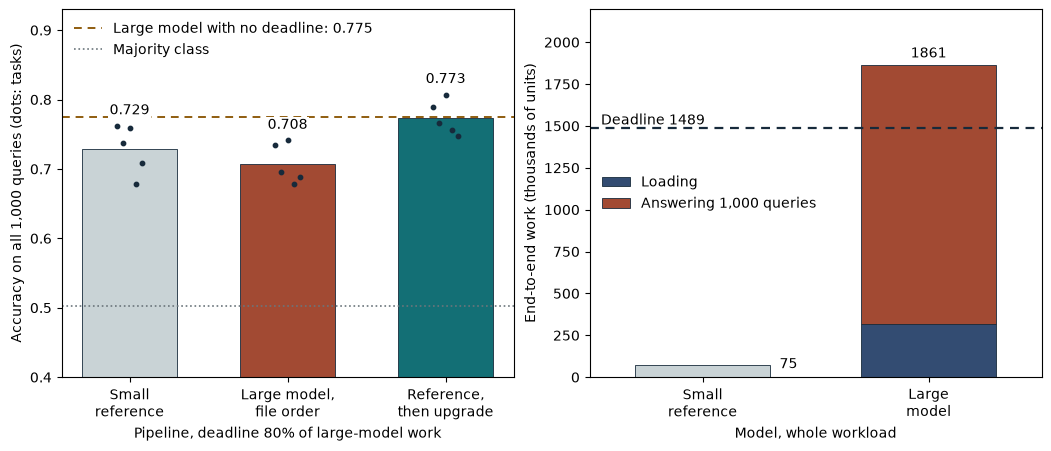

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch62 import draw, NCOLS, HEIGHT

DEFAULT = 80
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a deadline of 80% of the large model's work, the large model in file order answers 76% of the queries and scores 0.708 overall, against 0.729 for the small reference: 0.729 - 0.708 = 0.021 lower. Given unlimited time it would score 0.775, 0.775 - 0.729 = 0.046 above the reference. Reference-then-upgrade scores 0.773 and upgrades 71% of queries to the large model, recovering 95% of that gain. The large model needs 25 times the small model's work.

- Large model against reference: 0.708 - 0.729 = -0.021.
- Gain with no deadline: 0.775 - 0.729 = 0.046.
- Reference-then-upgrade against reference: 0.773 - 0.729 = 0.044.
- Deadline in work units: 1489 thousand, against 1861 thousand needed by the large model.

## Apply this to your competition

- Measure load time and per-query time of every pipeline stage on a slice of the real test data, then scale to the test size and compare with the cap.
- Keep a pipeline that finishes comfortably as the reference, and save its predictions before any experiment that risks the cap.
- Compare completed answers under the deadline, not completed-query accuracy alone.
- Treat a routing rule (which queries get the expensive model) as its own experiment with its own quality and cost.

Book location: Chapter 62, Quality Includes Completed Work.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)